# Part 4. Scaling up, and the real(ish) problem

Building the method by hand was the point: now you know what is under the hood. In practice you reach for a library that handles the parts we skipped, like optimizing the acquisition properly, fitting hyperparameters, noise, batches, and several objectives at once.

We use two. First scikit-learn, to confirm its Gaussian process reproduces what you built. Then Optuna, which Module 4 pointed at and which you will use hands on in Module 5, to attack the twelve-knob beamline.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for cand in [here, *here.parents]:
    if (cand / "blackbox").is_dir():
        if str(cand) not in sys.path:
            sys.path.insert(0, str(cand))
        break

import numpy as np
import matplotlib.pyplot as plt
from blackbox import plotting
plotting.use_clean_style()

from blackbox import forrester, VirtualBeamline

## The library version of your model

Here is scikit-learn fitting a Gaussian process to a handful of Forrester points. It is the same idea you implemented, with the hyperparameters fit for you. The picture should look familiar.

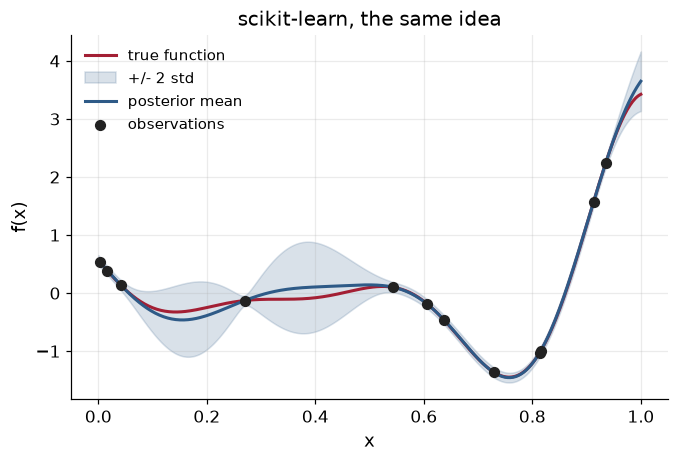

In [2]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

xx = np.linspace(0, 1, 400)
_raw = forrester(xx); shift, spread = _raw.mean(), _raw.std()
def f(x):
    return (forrester(np.asarray(x, dtype=float)) - shift) / spread

rng = np.random.default_rng(0)
X_obs = np.sort(rng.uniform(0, 1, size=12))
y_obs = f(X_obs)

kernel = (ConstantKernel(1.0, (0.1, 10.0))
          * RBF(0.2, length_scale_bounds=(0.05, 1.0))
          + WhiteKernel(1e-3, "fixed"))
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5,
                               normalize_y=True).fit(X_obs[:, None], y_obs)
mean, std = gpr.predict(xx[:, None], return_std=True)

plotting.plot_gp_1d(xx, mean, std, X_obs, y_obs, truth=f(xx),
                    title="scikit-learn, the same idea")
plt.show()

## The hard problem

Now the twelve-knob machine. A plain Gaussian process with one lengthscale starts to struggle past fifteen or so dimensions, which is the lecture's warning about vanilla Bayesian optimization in high dimensions. Optuna ships samplers built for this. We run it with the time cost switched off so the search finishes in class, but keep counting trials as the bill.

Write the objective: read twelve voltages out of the trial, measure the beam, and return the total counts. We want to maximize.

In [3]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

beam = VirtualBeamline(seconds_per_eval=0.0, seed=0)

c:\Users\Administrador\anaconda3\envs\env_name\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def objective(trial):
    # TODO: suggest twelve floats v0..v11, each between -1 and 1, into a list v.
    # Then measure: nx, ny = beam.evaluate(v, fast=True), and return nx + ny.
    v = [trial.suggest_float(f'v{i}', -1, 1) for i in range(12)]
    nx, ny = beam.evaluate(v, fast=True)
    return nx + ny

Run two searches with the same budget: Optuna's default sampler (a tree-structured Parzen estimator, which is a Bayesian method) against plain random sampling. Compare how fast each climbs.

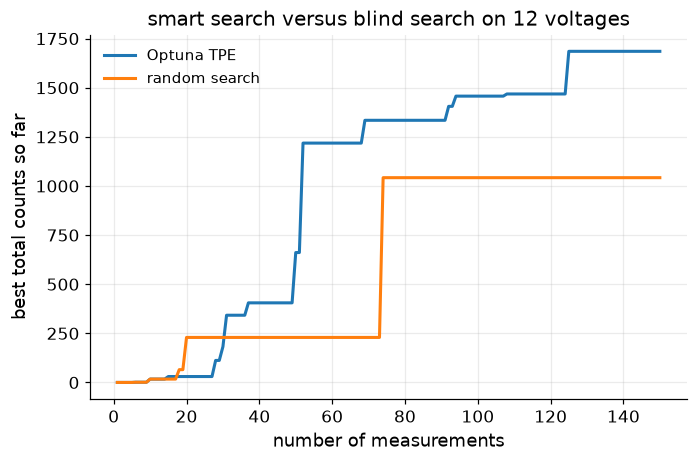

best total counts, TPE:    1685
best total counts, random: 1042


In [5]:
budget = 150

study_smart = optuna.create_study(direction="maximize",
                                   sampler=optuna.samplers.TPESampler(seed=1))
study_smart.optimize(objective, n_trials=budget)

study_random = optuna.create_study(direction="maximize",
                                    sampler=optuna.samplers.RandomSampler(seed=1))
study_random.optimize(objective, n_trials=budget)

def best_curve(study):
    vals = np.array([t.value for t in study.trials])
    return np.maximum.accumulate(vals)

plt.plot(range(1, budget + 1), best_curve(study_smart), label="Optuna TPE")
plt.plot(range(1, budget + 1), best_curve(study_random), label="random search")
plt.xlabel("number of measurements"); plt.ylabel("best total counts so far")
plt.legend(); plt.title("smart search versus blind search on 12 voltages"); plt.show()

print("best total counts, TPE:   ", int(study_smart.best_value))
print("best total counts, random:", int(study_random.best_value))

> **Discuss.** The space has a decoy: a second region that gives decent counts but tops out well below the real optimum. Did either search look like it parked in a mediocre region for a while? What would you change to push it to keep exploring?

## Two objectives that fight

So far we collapsed the two detectors into one number. But `Nx` and `Ny` are in tension: the focus that raises the counts in x lowers them in y past a point. There is no single best setting, there is a trade-off curve. This is exactly the transmission versus emittance picture from the lecture.

Optuna can optimize both at once and return the Pareto front, the set of settings where you cannot improve one detector without giving up on the other.

In [6]:
def objective_mo(trial):
    v = [trial.suggest_float("v" + str(i), -1.0, 1.0) for i in range(beam.dim)]
    nx, ny = beam.evaluate(v, fast=True)
    # TODO: return both objectives so Optuna can trade them off.
    return nx, ny

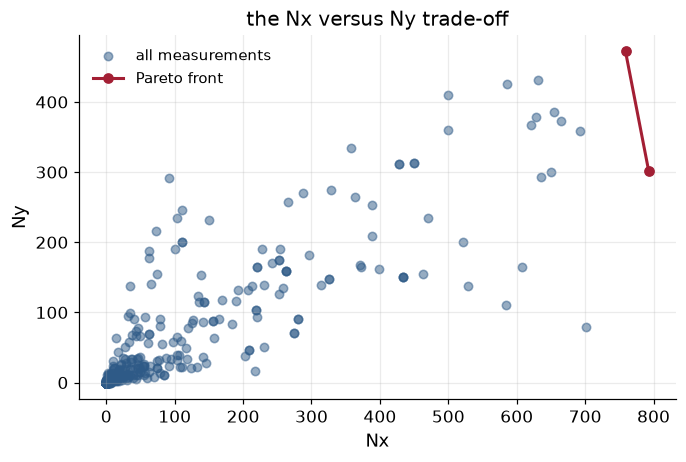

settings on the Pareto front: 2


In [7]:
beam = VirtualBeamline(seconds_per_eval=0.0, seed=0)   # fresh noise, so the run is reproducible

study_mo = optuna.create_study(directions=["maximize", "maximize"],
                               sampler=optuna.samplers.NSGAIISampler(seed=1))
study_mo.optimize(objective_mo, n_trials=800)

all_values = np.array([t.values for t in study_mo.trials])

ax = plotting.plot_pareto(all_values, label="all measurements")
ax.set_title("the Nx versus Ny trade-off"); plt.show()
print("settings on the Pareto front:", len(plotting.pareto_front(all_values)))

The red curve is the set of achievable trade-offs. If the experiment needs a tight beam in x you read off one end; if it needs balance you read off the middle. There is no setting that wins on both, and the curve shows you the price of each compromise. The blue cloud below it is every setting that got tried but is beaten by something on the front.

## The bridge to Module 6

Look back at what you collected. Every trial was a setting and its measured counts, a table of voltages mapped to `(Nx, Ny)`. That table is training data. In the next module you fit a fast model to it, an emulator, that predicts the counts without running the slow machine at all. Then you can search the emulator in milliseconds and only spend real measurements to confirm.

In [9]:
records = []
for t in study_mo.trials:
    v = [t.params["v" + str(i)] for i in range(beam.dim)]
    records.append(v + list(t.values))
data = np.array(records)
print("collected dataset shape:", data.shape, "(12 voltages + Nx + Ny per row)")
np.save("../data/beamline_runs.npy", data)   # uncomment to keep it for Module 6

collected dataset shape: (800, 14) (12 voltages + Nx + Ny per row)


## What you did this morning

You started with a problem you could not brute force. You built a Gaussian process from scratch and saw it report honest uncertainty. You turned that uncertainty into a decision with an acquisition function, and you watched the loop beat blind search. Then you scaled the same ideas to a hard twelve-knob problem with a library, found a trade-off front, and ended holding the data an emulator needs.

If you want to go further: Frazier's tutorial (arXiv:1807.02811) is a clean read on Bayesian optimization, Rasmussen and Williams (free online) is the canonical Gaussian process text, and the Optuna and BoTorch docs are good next stops for real work.